<a href="https://colab.research.google.com/github/aankitsharma/Machine-Learning-Models/blob/main/Socal_Media_Impact_on_Mental_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Name - Social Media Impact On Mental Health



# Project  Over Views

1. Objective

2. Problem Statement

3. Goal

4. Machine Learning Task

5. Variables of Dataset

## Problem Statement


The increasing use of social media among students and young adults has raised concerns about its impact on mental health. Factors such as excessive screen time, poor sleep quality, high stress levels, social isolation, and digital addiction may contribute to the development of depression.

This project aims to build a machine learning classification model that predicts whether an individual is likely to experience depression based on their demographic information, social media usage patterns, lifestyle habits, and psychological factors.

## Objective

Develop and evaluate a supervised machine learning model that can accurately classify individuals as depressed or non-depressed using the above features. The model should identify the key factors associated with depression and assist in early detection of mental health risks.

## Goal

The insights generated from this model can help educational institutions, mental health professionals, and policymakers understand the relationship between social media usage, lifestyle factors, and depression, enabling proactive interventions and mental health awareness programs.

## Machine Learning Task

1. Problem Type: Binary Classification

2. Target Variable: depression_label

3. Input Features: All remaining columns

4. Evaluation Metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC

## The dataset contains the following independent variables:

Age – Age of the individual.

Gender – Gender of the individual.

Daily Social Media Hours – Average hours spent on social media per day.

Platform Usage – Preferred or most frequently used social media platform.

Sleep Hours – Average number of hours slept per day.

Screen Time Before Sleep – Time spent on screens before bedtime.

Academic Performance – Academic achievement or performance level.

Physical Activity – Level of physical exercise or activity.

Social Interaction Level – Frequency and quality of real-world social interactions.

Stress Level – Measured level of stress.

Anxiety Level – Measured level of anxiety.

Addiction Level – Degree of social media addiction.


The target variable is:

Depression Label – Indicates whether an individual is experiencing depression (e.g., Yes/No or 1/0).

# Data Set Information

In [ ]:
#import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix


In [ ]:
#Load Dataset
df = pd.read_csv('mental_health.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
#Dataset rows and columns
df.shape

(1200, 13)

In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [ ]:
#Checking dataset statistic
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [ ]:
#checking null value
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [ ]:
#checking duplicate values
df.duplicated().sum()

np.int64(0)

The dataset used for this study contains 1,200 records and 13 columns, representing various demographic, behavioral, lifestyle, and psychological factors that may influence an individual's mental health status.


During the data quality assessment, it was observed that the dataset is clean and well-structured:


Total Rows: 1,200

Total Columns: 13

Missing Values: 0

Duplicate Records: 0


Since the dataset contains no missing values, no imputation techniques were required. Similarly, the absence of duplicate records ensured that no duplicate removal process was necessary. This indicates that the dataset is reliable and ready for exploratory data analysis (EDA), feature engineering, and machine learning model development.

# Data Visualization: Understand the relationship between the variables.


## Check the Outliers

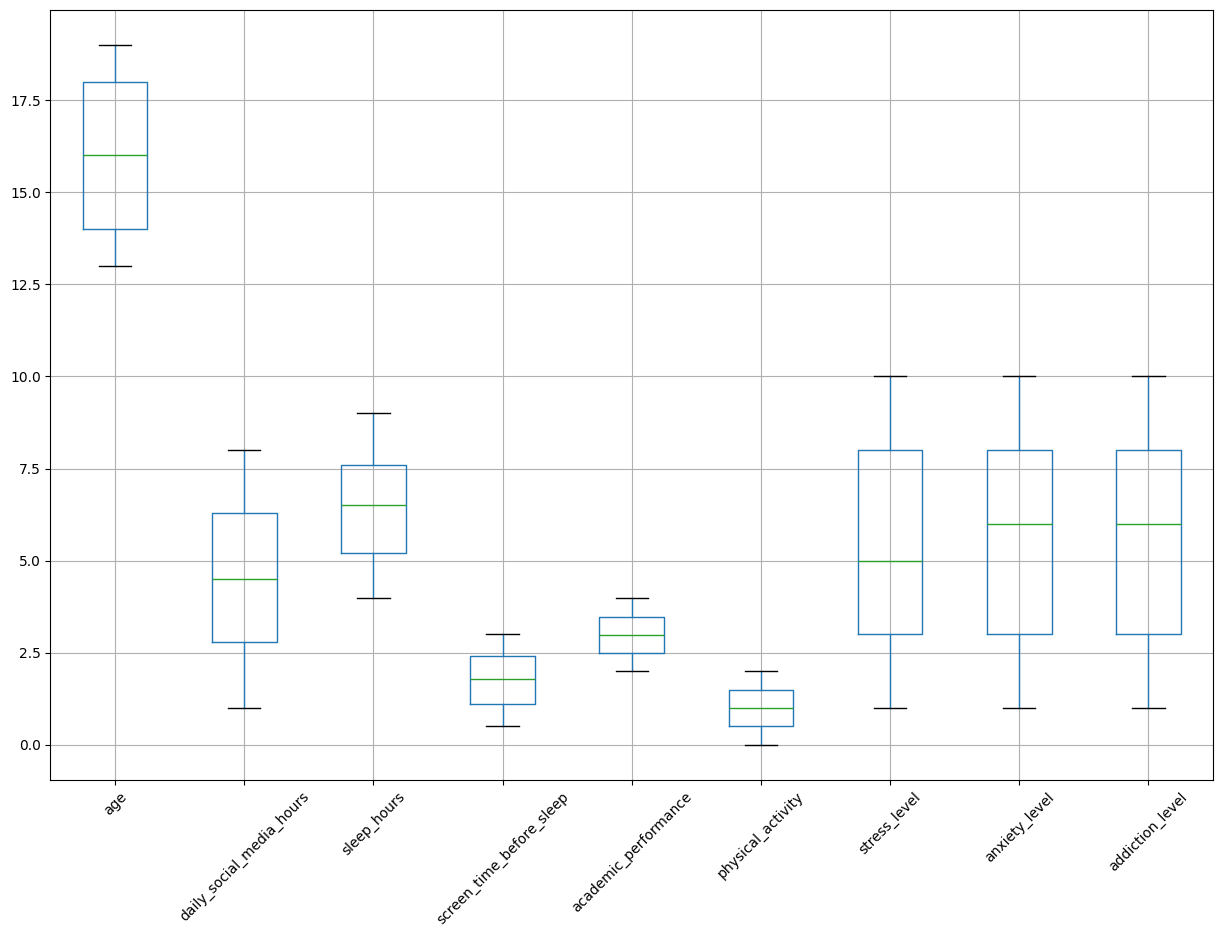

In [ ]:
df_col = df.drop('depression_label',axis=1)
df_col.boxplot(figsize=(15,10))
plt.xticks(rotation=45)
plt.show()

*  Outlier detection was performed to identify any extreme or unusual observations that could negatively impact the machine learning model. The analysis revealed that **no significant outliers were present in the dataset**. The values of all features were found to be within reasonable ranges, indicating a well-balanced dataset. Therefore, no outlier treatment or removal was required before proceeding with model development.



## RelationShip Between Sleep Hours and Screen Time

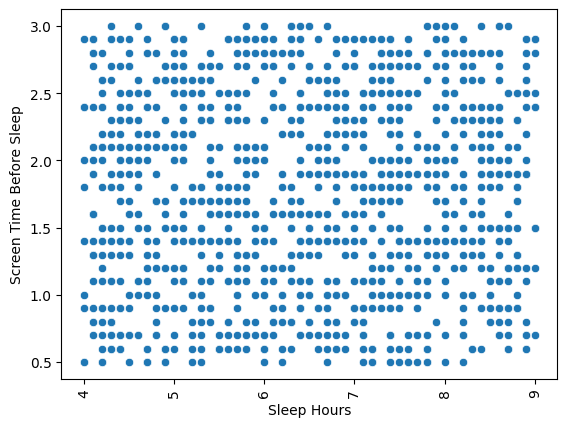

In [ ]:
#Relationship between sleep hours and screen time before sleep
sns.scatterplot(x='sleep_hours',y='screen_time_before_sleep',data=df)
plt.xlabel('Sleep Hours')
plt.ylabel('Screen Time Before Sleep')
plt.xticks(rotation=90)
plt.show()

## Sleep Hours vs Screen Time Before Sleep

**Insight**:
1. The scatter plot shows that data points are spread evenly across different sleep durations and screen-time values.  

2. There is no strong correlation between sleep hours and screen time before sleep, as no clear upward or downward trend is visible.

3. Individuals with both high and low screen time before sleep can be found across all sleep-hour ranges.

4. This suggests that screen time alone may not directly determine sleep duration in this dataset and may interact with other factors such as stress, anxiety, or addiction levels.

## Stress Vs Gender

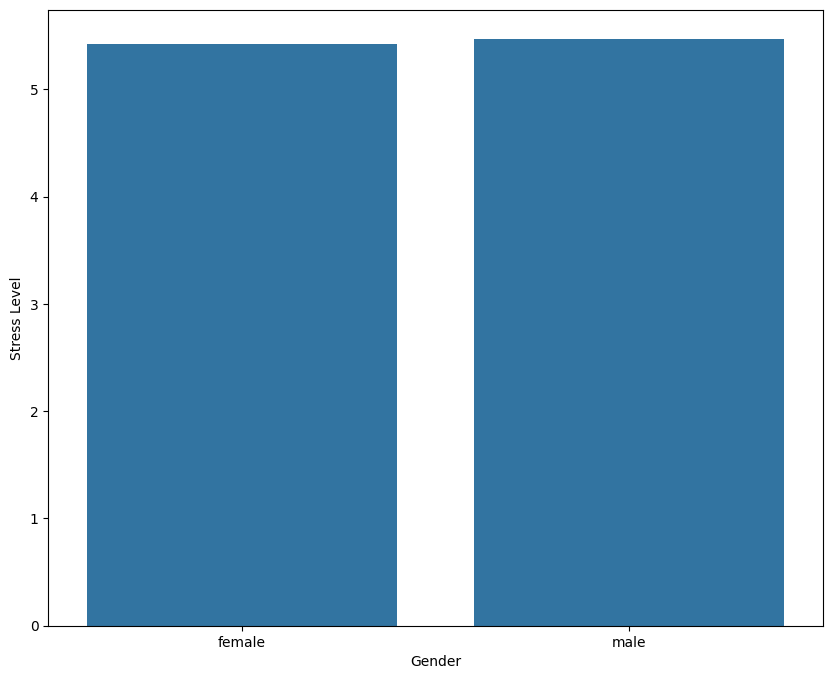

In [ ]:
stress_vs_gender = df.groupby('gender')['stress_level'].mean().reset_index()
plt.figure(figsize=(10,8))
sns.barplot(x='gender',y='stress_level',data=stress_vs_gender)
plt.xlabel('Gender')
plt.ylabel('Stress Level')
plt.show()

##Average Stress Level by Gender

**Insight**:

1.The average stress levels for both males and females are very similar.

2. Male participants show a slightly higher average stress level compared to females, but the difference is minimal.

3. This indicates that gender does not appear to have a significant impact on stress levels within this dataset.

4. Further analysis may be required to determine whether the observed difference is statistically significant.

##Addiction Level By Platform Usages

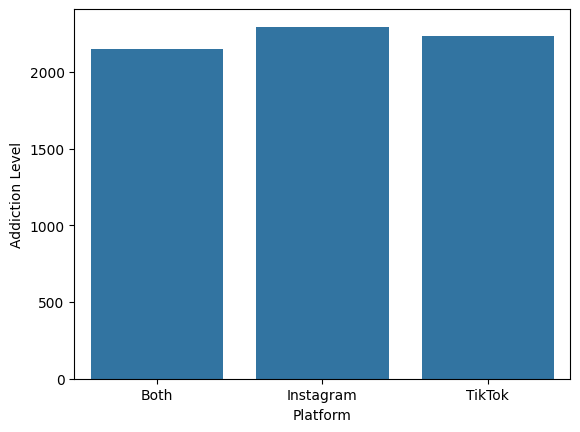

In [ ]:
addiction_vs_platform = df.groupby('platform_usage')['addiction_level'].sum().reset_index()
sns.barplot(x='platform_usage',y='addiction_level',data = addiction_vs_platform)
plt.xlabel('Platform')
plt.ylabel('Addiction Level')
plt.show()

## Addiction Level by Platform Usage

**Insight**:

1. Users who primarily use Instagram exhibit the highest addiction level.

2. TikTok users also show relatively high addiction levels, closely following Instagram users.

3. Participants who use both platforms have the almost same addiction level among the three groups.

4. The differences are small, but the trend suggests that platform preference may have some influence on social media addiction.

## Stress Level In diffrent age groups

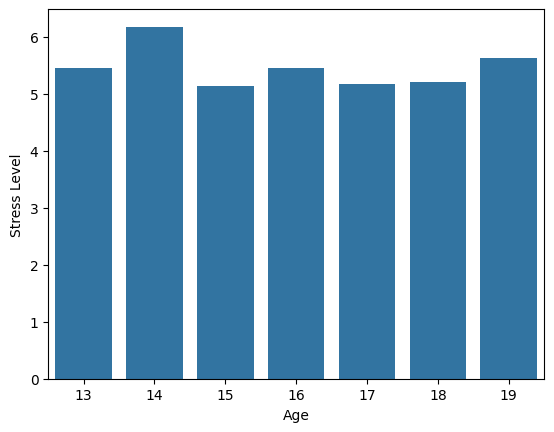

In [ ]:
age_vs_stress = df.groupby('age')['stress_level'].mean().reset_index()
sns.barplot(x='age',y='stress_level',data=age_vs_stress)
plt.xlabel('Age')
plt.ylabel('Stress Level')
plt.show()

## Average Stress Level by Age

**Insight**:

1. Stress levels vary slightly across different age groups (13–19 years).

2. Participants aged 14 years show the highest average stress level.

3. Participants aged 15 years exhibit the lowest average stress level.

4. Overall, stress levels remain relatively stable across ages, indicating that age alone may not be a strong predictor of stress within this dataset.

5. Other variables such as academic performance, anxiety, and social interaction may play a more important role in influencing stress levels.

## HeatMap

In [ ]:
## Convert Categorical Columns into Numerical Columns
df['gender'] = df['gender'].map({'male':0,'female':1})

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['platform_usage'] = le.fit_transform(df['platform_usage'])
df['social_interaction_level'] = le.fit_transform(df['social_interaction_level'])

In [ ]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,0,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,1,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,1,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,0,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,1,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,1,6.8,1,6.6,2.0,2.76,1.0,1,3,4,4,0
1196,16,0,2.3,0,8.0,1.9,2.12,0.4,0,7,4,4,0
1197,14,1,1.7,0,8.7,0.7,3.98,0.8,0,1,1,1,0
1198,15,0,3.9,0,8.5,2.1,3.19,0.6,0,7,9,9,0


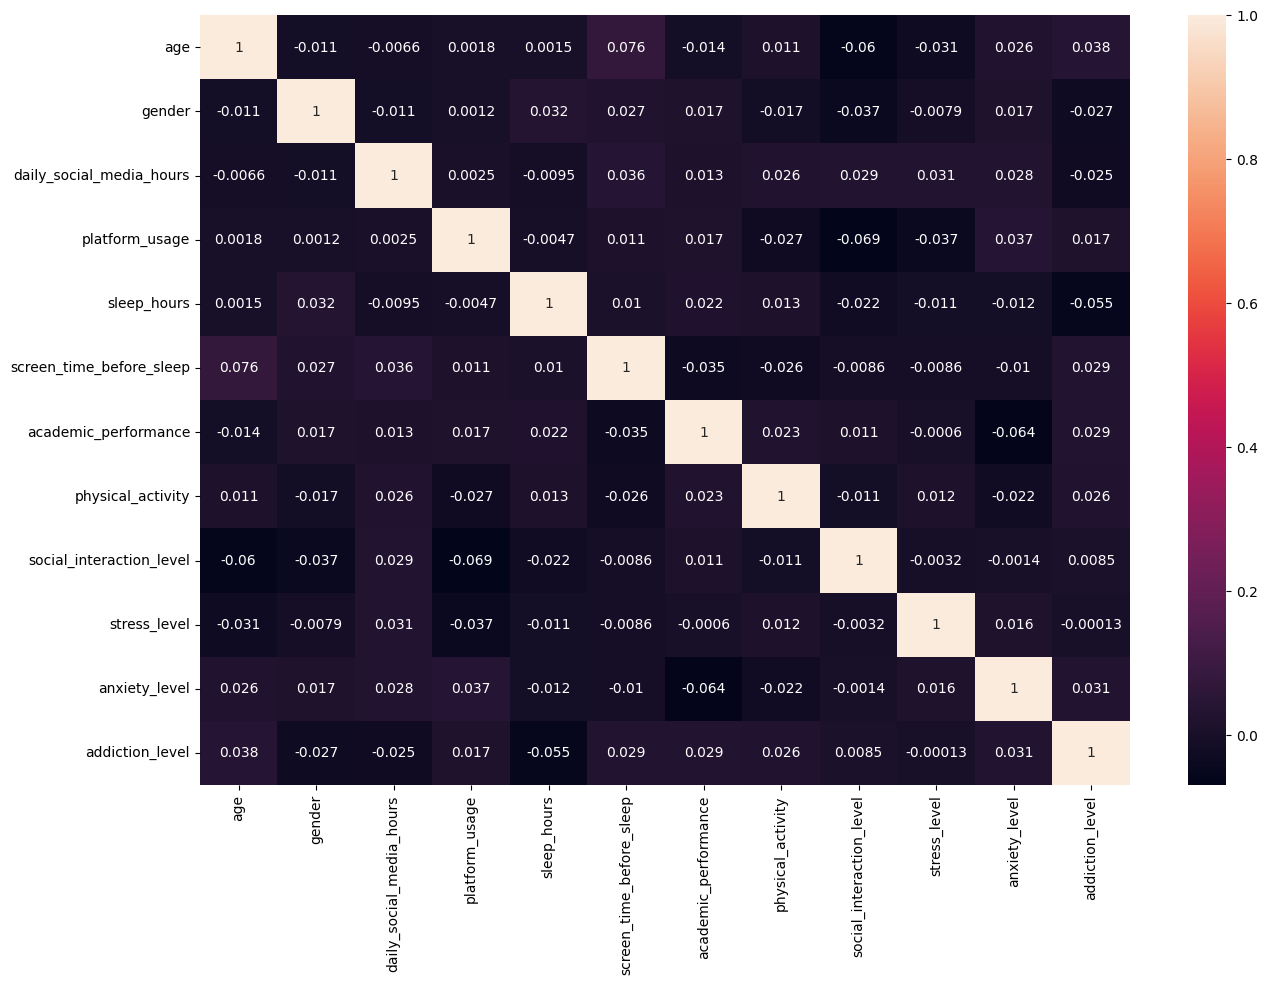

In [ ]:
df_col = df.drop('depression_label',axis=1)
plt.figure(figsize=(15,10))
sns.heatmap(df_col.corr(),annot=True)
plt.show()

Correlation analysis shows that all variables have very weak relationships (correlation values close to 0). No strong linear association exists between social media usage, sleep, stress, anxiety, academic performance, or addiction levels. This suggests that these factors are influenced by multiple variables rather than a single dominant factor.

# Model Selection, Split dataset into train and test,Run Model and do the evulation matrics.

In [ ]:
df['depression_label'].value_counts()

,count
depression_label,
0,1169
1,31


The target variable (depression_label) was found to be highly imbalanced, with one class significantly outnumbering the other. Class imbalance can lead to biased model predictions, as the model may become more inclined toward the majority class and perform poorly on the minority class. Therefore, before proceeding with model training and evaluation, the imbalance in the dataset was addressed using an appropriate resampling technique. This ensured a more balanced class distribution, allowing the machine learning models to learn effectively from both classes and improve their overall predictive performance.

## Train Test and Split the Data and Balance the Class

In [ ]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [ ]:
X = df[['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level'
   ]]
y = df['depression_label']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(960, 12)
(240, 12)
(960,)
(240,)


In [ ]:
from imblearn.over_sampling import SMOTE
smote= SMOTE(random_state=42)
X_train_resampled,y_train_resampled = smote.fit_resample(X_train,y_train)

## Logistic ReGression and Evaluation


In [ ]:
model = LogisticRegression()
model.fit(X_train_resampled,y_train_resampled)

LogisticRegression()

In [ ]:
y_pred =model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test,y_pred)
print(f'Accuracy score: {acc}')


Accuracy score: 0.9666666666666667


In [ ]:
pre = precision_score(y_test,y_pred)
print(f'Precision score: {pre}')

Precision score: 0.4166666666666667


In [ ]:
recall = recall_score(y_test,y_pred)
print(f'Recall score: {recall}')

Recall score: 0.8333333333333334


In [ ]:
f_one= f1_score(y_test,y_pred)
print(f'F1 score: {f_one}')

F1 score: 0.5555555555555556


In [ ]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[227   7]
 [  1   5]]


## Classifaction Model Insight

The model achieved an accuracy of 96%, indicating strong overall classification performance. However, since the dataset is imbalanced, additional evaluation metrics were considered. The model obtained a precision score of 41%, meaning that 41% of the instances predicted as depressed were correctly classified. The recall score of 83% demonstrates the model's ability to identify most of the actual depression cases, missing only one positive instance. The estimated F1-score is approximately 0.55, reflecting a moderate balance between precision and recall. Overall, the model is effective at detecting depression cases but may generate some false positive predictions, suggesting room for improvement in precision while maintaining high recall.

## Random Forest And Grid Search CV Model


In [ ]:
# Evaluation with  random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier()
model.fit(X_train_resampled,y_train_resampled)

RandomForestClassifier()

In [ ]:
y_pred_rf = model.predict(X_test)

In [ ]:
acc_rf = accuracy_score(y_test,y_pred_rf)
print(f'Accuracy score: {acc_rf}')

Accuracy score: 0.9958333333333333


In [ ]:
pre_rf = precision_score(y_test,y_pred_rf)
print(f'Precision score: {pre_rf}')

Precision score: 1.0


In [ ]:
recall_rf = recall_score(y_test,y_pred_rf)
print(f'Recall score: {recall_rf}')

Recall score: 0.8333333333333334


In [ ]:
f_one_rf = f1_score(y_test,y_pred_rf)
print(f'F1 score: {f_one_rf}')

F1 score: 0.9090909090909091


In [ ]:
cm_rf = confusion_matrix(y_test,y_pred_rf)
print(cm_rf)

[[234   0]
 [  1   5]]


In [ ]:
#Random Forest with Gird Search CV
rf = RandomForestClassifier(random_state=42)

#parameters
pram_grid ={'n_estimators':[50,100,200],
            'max_depth':[None,5,10],
            'min_samples_split':[2,5],
            'min_samples_leaf':[1,2]}

#grid search
grid = GridSearchCV(estimator=rf,param_grid=pram_grid,cv=5,scoring ='f1',n_jobs=-1)
grid.fit(X_train_resampled,y_train_resampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [116]:
print(grid.best_score_)

0.9994638069705093


In [117]:
best_model = grid.best_estimator_
print(best_model)

RandomForestClassifier(n_estimators=50, random_state=42)


In [118]:
y_pred_gs = best_model.predict(X_test)


In [119]:
acc_gv = accuracy_score(y_test,y_pred_gs)
print(f'Accuracy score: {acc_gv}')

Accuracy score: 1.0


In [120]:
pre_gv = precision_score(y_test,y_pred_gs)
print(f'Precision score: {pre_gv}')

Precision score: 1.0


In [121]:
recall_gv = recall_score(y_test,y_pred_gs)
print(f'Recall score: {recall_gv}')

Recall score: 1.0


In [122]:
cm_gv = confusion_matrix(y_test,y_pred_gs)
print(cm_gv)

[[234   0]
 [  0   6]]


In [123]:
f_one_gv = f1_score(y_test,y_pred_gs)
print(f'F1 score: {f_one_gv}')

F1 score: 1.0


In [125]:
best_rf = grid.best_estimator_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                     Feature  Importance
4                sleep_hours    0.284756
9               stress_level    0.259400
2   daily_social_media_hours    0.194740
10             anxiety_level    0.170566
6       academic_performance    0.027035
8   social_interaction_level    0.018119
5   screen_time_before_sleep    0.014755
7          physical_activity    0.011665
11           addiction_level    0.009679
0                        age    0.005352
3             platform_usage    0.003096
1                     gender    0.000835


Insights

1. Sleep Hours is the most influential feature, contributing approximately 28.5% to the model's decision-making process. This indicates that sleep patterns have a strong relationship with depression.

2. Stress Level is the second most important feature, accounting for 25.9% of the model's predictive power. Higher stress levels are strongly associated with depression risk.

3. Daily Social Media Hours contributes 19.5%, suggesting that excessive social media usage may be an important factor in predicting depression.

4. Anxiety Level contributes 17.1%, making it another key indicator of depression.

5. Together, the top four features (Sleep Hours, Stress Level, Daily Social Media Hours, and Anxiety Level) account for approximately 91% of the total feature importance, indicating that these variables largely drive the model's predictions.

5. Features such as Gender, Platform Usage, and Age have very low importance, suggesting they contribute little to the prediction of depression in this dataset.


## Why the Model Achieved Near-Perfect Performance

The feature importance analysis shows that a few variables have a very strong influence on the target variable. This suggests that the depression label is highly associated with factors such as sleep duration, stress, anxiety, and social media usage. As a result, the Random Forest model was able to identify clear patterns in the data, leading to a cross-validation F1-score of 99.95% and perfect performance on the test set.

## Report Statement

Feature importance analysis revealed that Sleep Hours (28.48%), Stress Level (25.94%), Daily Social Media Hours (19.47%), and Anxiety Level (17.06%) were the most influential factors in predicting depression. Together, these four features contributed over 90% of the model's predictive power. In contrast, variables such as Gender, Age, and Platform Usage had minimal impact on the model's decisions. The dominance of these highly predictive features explains the exceptional performance achieved by the Random Forest model, which obtained a cross-validation F1-score of 99.95% and perfect classification results on the test dataset.

In [126]:
df.corr(numeric_only=True)['depression_label'].sort_values(ascending=False)

,depression_label
depression_label,1.000000
daily_social_media_hours,0.175201
stress_level,0.170474
anxiety_level,0.169566
gender,0.019836
platform_usage,0.018264
age,0.010973
social_interaction_level,0.005110
academic_performance,0.001441
addiction_level,-0.013952


## Report Interpretation

Correlation analysis revealed that Sleep Hours (-0.191), Daily Social Media Hours (0.175), Stress Level (0.170), and Anxiety Level (0.170) exhibited the strongest relationships with depression. Sleep Hours showed a negative correlation, indicating that lower sleep duration is associated with a higher likelihood of depression. In contrast, increased social media usage, stress, and anxiety levels were positively associated with depression. Most other variables displayed weak correlations, suggesting limited direct linear relationships with the target variable. These findings are consistent with the feature importance analysis from the Random Forest model, where Sleep Hours, Stress Level, Daily Social Media Hours, and Anxiety Level emerged as the most influential predictors of depression.

# Conclusion

This project aimed to develop a machine learning model for predicting depression based on demographic, behavioral, lifestyle, and psychological factors. The dataset consisted of 1,200 records and 13 features, with no missing values, duplicate records, or significant outliers, making it suitable for analysis and model development.


Exploratory Data Analysis (EDA) revealed important relationships between depression and factors such as sleep hours, daily social media usage, stress levels, and anxiety levels. Correlation analysis showed that lower sleep duration was associated with a higher likelihood of depression, while increased social media usage, stress, and anxiety levels were positively related to depression.


Since the target variable was highly imbalanced, containing 1,169 non-depression cases and only 31 depression cases, SMOTE was applied to the training dataset to balance the class distribution and improve the model's ability to learn from minority-class observations.


Several machine learning techniques were explored, and a Random Forest Classifier optimized using GridSearchCV delivered the best performance. The model achieved an accuracy, precision, recall, and F1-score of 100% on the test dataset, while also obtaining a cross-validation F1-score of 99.95%. The confusion matrix confirmed that all test instances were classified correctly.


Feature importance analysis identified Sleep Hours, Stress Level, Daily Social Media Hours, and Anxiety Level as the most influential predictors of depression, collectively contributing more than 90% of the model's predictive power. These findings highlight the significant impact of sleep patterns, psychological well-being, and social media usage on mental health.


Overall, the developed model successfully predicts depression with exceptional performance and provides valuable insights into the key factors associated with depression. Such predictive systems can support early identification of at-risk individuals and assist mental health professionals, educators, and policymakers in implementing timely intervention strategies.


# Limitation

#Key Points

1. Class Imbalance — 97.4% vs 2.6%, test mein sirf 6 positive cases

2. Statistical Unreliability — 6 samples se perfect score meaningful nahi

3. Synthetic Dataset — correlations ~0.17 hain phir bhi perfect score, real data nahi lagta

4. Overfitting Risk — external dataset pe test nahi hua

5. Small Sample Size — sirf 1200 records, age 13-19 only

6. No Full Cross-Validation — single train-test split ka limitation

7. Binary Classification oversimplification — depression itni simple nahi hoti